# Expanding the Dataset

This notebook is how I created the final dataset by using the YouTube API. 

I will be finding 8 videos per player, and then 25 comments per video. This will result in 40 videos total, and 1000 comments. 

### Imports

In [22]:
import pandas as pd
import requests
import time
import os
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

### Filtering the ATP Tennis Matches Dataset

This cell is filtering the tennis dataset based on the player, and finding 8 matches to be used. It creates a new dataset where these matches are rows, and will then be used to find the YouTube videos, and then the comments from those videos. 

This cell should return a new dataset with just the 40 chosen matches from all of the players:

- Sinner
- Alcaraz
- Zverev
- Djokovic
- Medvedev

In [10]:
df_tennis = pd.read_csv('atp_tennis.csv')
# making sure its datetime format
df_tennis['Date'] = pd.to_datetime(df_tennis['Date'])

# filtering for dates after 2016...will likely not matter in the end
df_tennis = df_tennis[df_tennis['Date'].dt.year >= 2016]

# creating the mean rank column
df_tennis['Rank_Mean'] = df_tennis[['Rank_1', 'Rank_2']].mean(axis=1)

# creating the upset column
df_tennis['Upset'] = df_tennis.apply(lambda row: (row['Rank_1'] > row['Rank_2'] and row['Winner'] == row['Player_1']) or (row['Rank_2'] > row['Rank_1'] and row['Winner'] == row['Player_2']), axis=1)

# the parameters for choosing matches
n_matches = 8
n_days_between_matches = 14
max_same_opponent = 3

player_list = ['Sinner', 'Alcaraz', 'Zverev', 'Djokovic', 'Medvedev']

chosen_matches = []
# to make sure there aren;t duplicate matches
selected_match_keys = set()


for player in player_list:
    # filter matches for the player (had to add the .copy bc I was getting python warnings before)
    player_matches = df_tennis[(df_tennis['Player_1'].str.contains(player)) | (df_tennis['Player_2'].str.contains(player))].copy()
    player_matches = player_matches[player_matches['Rank_Mean'] <= 12]  # filter for matches where the mean rank is 20 or better
    # assign selected player and opponent columns
    player_matches['Selected_Player'] = player
    player_matches['Opponent'] = player_matches.apply(lambda row: row['Player_2'] if player in row['Player_1'] else row['Player_1'], axis=1)
    # sort matches by date in descending order
    player_matches = player_matches.sort_values(by='Date', ascending=False)

    selected_matches = []
    selected_tournaments = set()
    opponent_counts = {}

    # iterate through the matches for the player
    for _, match in player_matches.iterrows():
        tournament_key = (match['Tournament'], match['Date'])

        match_key = tuple(sorted([
            match['Player_1'],
            match['Player_2']
        ])) + (match['Tournament'], match['Date'])

        opponent = match['Opponent']
        # check if the tournament has already been selected
        if tournament_key in selected_tournaments:
            continue
        # check if the match has already been selected
        if match_key in selected_match_keys:
            continue
        # check if the opponent has been faced too many times
        if opponent_counts.get(opponent, 0) >= max_same_opponent:
            continue
        # check if the match is within the required date range
        too_close = False
        for selected_match in selected_matches:
            days_apart = abs((match['Date'] - selected_match['Date']).days)
            if days_apart < n_days_between_matches:
                too_close = True
                break
        if too_close:
            continue

        # if all conditions are met, select the match
        selected_matches.append(match)
        selected_tournaments.add(tournament_key)
        selected_match_keys.add(match_key)
        opponent_counts[opponent] = opponent_counts.get(opponent, 0) + 1

        # check if we have selected enough matches
        if len(selected_matches) == n_matches:
            break

    chosen_matches.extend(selected_matches)

df_chosen_matches = pd.DataFrame(chosen_matches).reset_index(drop=True)

df_chosen_matches



,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,Rank_Mean,Upset,Selected_Player,Opponent
0,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,1,9300,10430,2.00,1.83,6-4 4-6 4-6 4-6,1.5,False,Sinner,Alcaraz C.
1,French Open,2025-06-08,Grand Slam,Outdoor,Clay,The Final,5,Alcaraz C.,Sinner J.,Alcaraz C.,...,1,8850,10380,2.00,1.83,4-6 6-7 6-4 7-6 7-6,1.5,True,Sinner,Alcaraz C.
2,Internazionali BNL d'Italia,2025-05-18,Masters 1000,Outdoor,Clay,The Final,3,Sinner J.,Alcaraz C.,Alcaraz C.,...,3,9730,7850,1.62,2.30,6-7 1-6,2.0,True,Sinner,Alcaraz C.
3,Australian Open,2025-01-26,Grand Slam,Outdoor,Hard,The Final,5,Sinner J.,Zverev A.,Sinner J.,...,2,11830,7635,1.33,3.40,6-3 7-6 6-3,1.5,False,Sinner,Zverev A.
4,Masters Cup,2024-11-17,Masters Cup,Indoor,Hard,The Final,3,Fritz T.,Sinner J.,Sinner J.,...,1,4300,10330,5.50,1.14,4-6 4-6,3.0,False,Sinner,Fritz T.
5,Shanghai Masters,2024-10-13,Masters 1000,Outdoor,Hard,The Final,3,Sinner J.,Djokovic N.,Sinner J.,...,4,11010,5560,1.40,3.00,7-6 6-3,4.0,False,Sinner,Djokovic N.
6,US Open,2024-09-08,Grand Slam,Outdoor,Hard,The Final,5,Fritz T.,Sinner J.,Sinner J.,...,1,3120,9360,4.00,1.25,3-6 4-6 5-7,6.5,False,Sinner,Fritz T.
7,Western & Southern Financial Group Masters,2024-08-18,Masters 1000,Outdoor,Hard,Semifinals,3,Zverev A.,Sinner J.,Sinner J.,...,1,6995,8770,2.63,1.50,6-7 7-5 6-7,2.5,False,Sinner,Zverev A.
8,Wimbledon,2025-07-11,Grand Slam,Outdoor,Grass,Semifinals,5,Fritz T.,Alcaraz C.,Alcaraz C.,...,2,4635,9300,4.75,1.17,4-6 7-5 3-6 6-7,3.5,False,Alcaraz,Fritz T.
9,French Open,2025-06-03,Grand Slam,Outdoor,Clay,Quarterfinals,5,Alcaraz C.,Paul T.,Alcaraz C.,...,12,8850,3210,1.08,8.00,6-0 6-1 6-4,7.0,False,Alcaraz,Paul T.


### Searching For the Videos

This cell uses the dataset created above to get the videos for all of the matches. It goes through each match, one by one, and appends the video details to the row.

This cell should return an updated 40 row dataset with the video details from YouTube API. 

In [11]:
# retrieving API key from env variable (stored in terminal)
YOUTUBE_API_KEY = os.getenv('YOUTUBE_API_KEY')

youtube_rows = []

# loop through rows of the matches and search for vid
for index, row in df_chosen_matches.iterrows():
    player_1 = row['Player_1'].replace(row['Player_1'].split()[-1], '').strip()
    player_2 = row['Player_2'].replace(row['Player_2'].split()[-1], '').strip()
    tournament = row['Tournament']
    year = pd.to_datetime(row['Date']).year

    # define the search query
    search_query = f"{player_1} vs {player_2} {tournament} {year} highlights"

    # search url for youtube videos
    search_url = "https://www.googleapis.com/youtube/v3/search"

    # parameters for the API request
    params = {
        "part": "snippet",
        "q": search_query,
        "type": "video",
        "maxResults": 1,
        "key": YOUTUBE_API_KEY
    }

    print(f"\nSearching for: {search_query}")

    # make the API request
    search_response = requests.get(search_url, params=params)
    print(f"Response status code: {search_response.status_code}")
    search_data = search_response.json()

    # create default null values in case there isn't a result
    video_id = None
    video_title = None
    channel_title = None
    published_at = None
    youtube_url = None

    if "items" in search_data and len(search_data["items"]) > 0:
        # grab the first result
        top_video = search_data["items"][0]
        
        # grab the video details
        video_id = top_video["id"]["videoId"]
        video_title = top_video["snippet"]["title"]
        channel_title = top_video["snippet"]["channelTitle"]
        published_at = top_video["snippet"]["publishedAt"]
        youtube_url = f"https://www.youtube.com/watch?v={video_id}"

        print(f"Found Video: {video_title}")
        print(f"Video ID: {video_id}")

    youtube_rows.append({
            "match_index": index,
            "youtube_search_query": search_query,
            "youtube_video_id": video_id,
            "youtube_video_title": video_title,
            "youtube_channel_title": channel_title,
            "youtube_published_at": published_at,
            "youtube_url": youtube_url
    })

    # added a manual pause in between just in case youtube has rate limits
    # I think it's just a straight 10k requests in a day, but just in case code goes wrong
    # THIS CELL TAKES EXACTLY 1 MIN TO RUN
    time.sleep(1.5)

df_youtube_vids = pd.DataFrame(youtube_rows)

df_matches_w_youtube_vids = df_chosen_matches.merge(df_youtube_vids, left_index=True, right_on='match_index', how='left')

df_matches_w_youtube_vids



Searching for: Alcaraz vs Sinner Wimbledon 2025 highlights
Response status code: 200
Found Video: An EPIC rivalry for the ages | Carlos Alcaraz v Jannik Sinner | Extended Highlights | Wimbledon 2025
Video ID: CxfFbGWS9qw

Searching for: Alcaraz vs Sinner French Open 2025 highlights
Response status code: 200
Found Video: Highlights Sinner vs Alcaraz Final | Roland-Garros 2025
Video ID: aERKJuBtIGw

Searching for: Sinner vs Alcaraz Internazionali BNL d'Italia 2025 highlights
Response status code: 200
Found Video: Jannik Sinner vs Carlos Alcaraz For The Title! 🏆 | Rome 2025 Final Highlights
Video ID: ebUixP8eMEw

Searching for: Sinner vs Zverev Australian Open 2025 highlights
Response status code: 200
Found Video: Jannik Sinner v Alexander Zverev Extended Highlights | Australian Open 2025 Final
Video ID: F5B1QpU0Evo

Searching for: Fritz vs Sinner Masters Cup 2024 highlights
Response status code: 200
Found Video: Jannik Sinner vs Taylor Fritz For The Title! 🏆 | Nitto ATP Finals 2024 Fina

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,Upset,Selected_Player,Opponent,match_index,youtube_search_query,youtube_video_id,youtube_video_title,youtube_channel_title,youtube_published_at,youtube_url
0,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,False,Sinner,Alcaraz C.,0,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw
1,French Open,2025-06-08,Grand Slam,Outdoor,Clay,The Final,5,Alcaraz C.,Sinner J.,Alcaraz C.,...,True,Sinner,Alcaraz C.,1,Alcaraz vs Sinner French Open 2025 highlights,aERKJuBtIGw,Highlights Sinner vs Alcaraz Final | Roland-Ga...,Roland-Garros,2025-06-08T21:27:52Z,https://www.youtube.com/watch?v=aERKJuBtIGw
2,Internazionali BNL d'Italia,2025-05-18,Masters 1000,Outdoor,Clay,The Final,3,Sinner J.,Alcaraz C.,Alcaraz C.,...,True,Sinner,Alcaraz C.,2,Sinner vs Alcaraz Internazionali BNL d'Italia ...,ebUixP8eMEw,Jannik Sinner vs Carlos Alcaraz For The Title!...,Tennis TV,2025-05-18T17:49:35Z,https://www.youtube.com/watch?v=ebUixP8eMEw
3,Australian Open,2025-01-26,Grand Slam,Outdoor,Hard,The Final,5,Sinner J.,Zverev A.,Sinner J.,...,False,Sinner,Zverev A.,3,Sinner vs Zverev Australian Open 2025 highlights,F5B1QpU0Evo,Jannik Sinner v Alexander Zverev Extended High...,Australian Open,2025-01-26T12:30:12Z,https://www.youtube.com/watch?v=F5B1QpU0Evo
4,Masters Cup,2024-11-17,Masters Cup,Indoor,Hard,The Final,3,Fritz T.,Sinner J.,Sinner J.,...,False,Sinner,Fritz T.,4,Fritz vs Sinner Masters Cup 2024 highlights,UnMnpAOSF2s,Jannik Sinner vs Taylor Fritz For The Title! 🏆...,Tennis TV,2024-11-17T19:21:24Z,https://www.youtube.com/watch?v=UnMnpAOSF2s
5,Shanghai Masters,2024-10-13,Masters 1000,Outdoor,Hard,The Final,3,Sinner J.,Djokovic N.,Sinner J.,...,False,Sinner,Djokovic N.,5,Sinner vs Djokovic Shanghai Masters 2024 highl...,fQfvkym38MM,Jannik Sinner vs Novak Djokovic For The Title ...,Tennis TV,2024-10-13T10:48:27Z,https://www.youtube.com/watch?v=fQfvkym38MM
6,US Open,2024-09-08,Grand Slam,Outdoor,Hard,The Final,5,Fritz T.,Sinner J.,Sinner J.,...,False,Sinner,Fritz T.,6,Fritz vs Sinner US Open 2024 highlights,Ycj5I3JKCT8,Jannik Sinner vs. Taylor Fritz Highlights | 20...,US Open Tennis Championships,2024-09-08T21:44:44Z,https://www.youtube.com/watch?v=Ycj5I3JKCT8
7,Western & Southern Financial Group Masters,2024-08-18,Masters 1000,Outdoor,Hard,Semifinals,3,Zverev A.,Sinner J.,Sinner J.,...,False,Sinner,Zverev A.,7,Zverev vs Sinner Western & Southern Financial ...,None,None,None,None,None
8,Wimbledon,2025-07-11,Grand Slam,Outdoor,Grass,Semifinals,5,Fritz T.,Alcaraz C.,Alcaraz C.,...,False,Alcaraz,Fritz T.,8,Fritz vs Alcaraz Wimbledon 2025 highlights,CX301bUuIJA,VAMOS Carlos! | Taylor Fritz vs Carlos Alcaraz...,Wimbledon,2025-07-11T16:28:08Z,https://www.youtube.com/watch?v=CX301bUuIJA
9,French Open,2025-06-03,Grand Slam,Outdoor,Clay,Quarterfinals,5,Alcaraz C.,Paul T.,Alcaraz C.,...,False,Alcaraz,Paul T.,9,Alcaraz vs Paul French Open 2025 highlights,GVqlb1BxFaM,Carlos Alcaraz vs Tommy Paul - FULL Quarterfin...,House of Highlights,2025-06-03T20:24:50Z,https://www.youtube.com/watch?v=GVqlb1BxFaM


### Searching For the Comments

This cell uses the dataset created above to get the top 25 comments from each video. It goes through each video and uses the video ID to grab comment info.

This cell should return an updated 1000 row dataset with the match, video, and comment details. 

In [13]:
# this entire cell is basically the exact same as the one above, just some differences in the params for comments
comment_rows = []

# parameters
comments_per_video = 25

for index, row in df_matches_w_youtube_vids.iterrows():
    video_id = row['youtube_video_id']

    print(f"\nFetching comments for video: {row['youtube_video_title']}")
    if pd.isna(video_id):
        print(f"No video found for {row['youtube_search_query']}, skipping the comments")
        continue

    comments_url = "https://www.googleapis.com/youtube/v3/commentThreads"

    params = {
        "part": "snippet",
        "videoId": video_id,
        "maxResults": comments_per_video,
        "order": "relevance",
        "textFormat": "plainText",
        "key": YOUTUBE_API_KEY
    }

    comments_response = requests.get(comments_url, params=params)
    print(f"Response status code: {comments_response.status_code}")
    comments_data = comments_response.json()

    # failsafe if there are no comments
    if "items" not in comments_data or len(comments_data["items"]) == 0:
        print(f"No comments found for video {row['youtube_video_title']}")
        continue
    
    # loop through the comments
    # different than the vid search because theres 25 of these instead of just grabbing the first one
    for comment_number, item in enumerate(comments_data["items"], start=1):
        comment = item["snippet"]["topLevelComment"]["snippet"]
        

        comment_text = comment["textDisplay"]
        comment_likes = comment["likeCount"]
        comment_published_at = comment["publishedAt"]

        comment_row = row.to_dict()

        comment_row["comment_number"] = comment_number
        comment_row["comment_text"] = comment_text
        comment_row["comment_likes"] = comment_likes
        comment_row["comment_published_at"] = comment_published_at

        comment_rows.append(comment_row)

    print(f"Fetched {len(comments_data['items'])} comments for video: {row['youtube_video_title']}")

    # added a manual pause again
    time.sleep(1.5)

df_comments = pd.DataFrame(comment_rows).reset_index(drop=True)

df_comments


Fetching comments for video: An EPIC rivalry for the ages | Carlos Alcaraz v Jannik Sinner | Extended Highlights | Wimbledon 2025
Response status code: 200
Fetched 25 comments for video: An EPIC rivalry for the ages | Carlos Alcaraz v Jannik Sinner | Extended Highlights | Wimbledon 2025

Fetching comments for video: Highlights Sinner vs Alcaraz Final | Roland-Garros 2025
Response status code: 200
Fetched 25 comments for video: Highlights Sinner vs Alcaraz Final | Roland-Garros 2025

Fetching comments for video: Jannik Sinner vs Carlos Alcaraz For The Title! 🏆 | Rome 2025 Final Highlights
Response status code: 200
Fetched 25 comments for video: Jannik Sinner vs Carlos Alcaraz For The Title! 🏆 | Rome 2025 Final Highlights

Fetching comments for video: Jannik Sinner v Alexander Zverev Extended Highlights | Australian Open 2025 Final
Response status code: 200
Fetched 25 comments for video: Jannik Sinner v Alexander Zverev Extended Highlights | Australian Open 2025 Final

Fetching comments

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,youtube_search_query,youtube_video_id,youtube_video_title,youtube_channel_title,youtube_published_at,youtube_url,comment_number,comment_text,comment_likes,comment_published_at
0,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw,1,The way he has recovered from that heartbreaki...,2512,2025-07-13T19:51:53Z
1,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw,2,This is one of most elite tennis I have ever s...,1140,2025-07-14T02:39:28Z
2,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw,3,"True champion! He doesn't scream, shout, or bo...",1531,2025-07-15T04:39:47Z
3,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw,4,I like how grounded the celebration is. Arms a...,755,2025-07-15T04:04:15Z
4,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,Alcaraz vs Sinner Wimbledon 2025 highlights,CxfFbGWS9qw,An EPIC rivalry for the ages | Carlos Alcaraz ...,Wimbledon,2025-07-13T19:45:54Z,https://www.youtube.com/watch?v=CxfFbGWS9qw,5,Alcaraz fan here to congratulate Jannik! His s...,786,2025-07-13T20:09:30Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,De Minaur vs Medvedev French Open 2024 highlights,FbyB1rIe5VU,Medvedev vs De Minaur Round 4 Highlights | Rol...,Roland-Garros,2024-06-03T17:18:49Z,https://www.youtube.com/watch?v=FbyB1rIe5VU,21,Alex's court coverage today was insane. He ju...,0,2024-06-04T01:56:56Z
878,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,De Minaur vs Medvedev French Open 2024 highlights,FbyB1rIe5VU,Medvedev vs De Minaur Round 4 Highlights | Rol...,Roland-Garros,2024-06-03T17:18:49Z,https://www.youtube.com/watch?v=FbyB1rIe5VU,22,I 've been watching DeMinaur for almost a coup...,6,2024-06-03T23:05:18Z
879,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,De Minaur vs Medvedev French Open 2024 highlights,FbyB1rIe5VU,Medvedev vs De Minaur Round 4 Highlights | Rol...,Roland-Garros,2024-06-03T17:18:49Z,https://www.youtube.com/watch?v=FbyB1rIe5VU,23,wow !,0,2024-06-03T19:42:41Z
880,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,De Minaur vs Medvedev French Open 2024 highlights,FbyB1rIe5VU,Medvedev vs De Minaur Round 4 Highlights | Rol...,Roland-Garros,2024-06-03T17:18:49Z,https://www.youtube.com/watch?v=FbyB1rIe5VU,24,De minaur court coverage are insane,2,2024-06-03T17:55:34Z


There are 882 rows instead of 1000, which just means that some videos didn't have enough comments for 25 each. That's ok! That's why I shot for the maximum amount of rows on the first go, just in case I fell short of the expected number. 882 rows still falls within the 500-1000 requirements. 

### Analyzing the Sentiment of Comments

Now that I have all of the comments, I'm able to loop through the entire dataset and gather the sentiment of all of the comments. This is done using VADER Sentiment Analysis. I will get numerical values for positive, neutral, and negative, and then a compund score that ranges from -1 to 1. From that value, I can programatically assign a value of "Positive", "Negative", or "Neutral".

In [15]:
# initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# renaming the dataset to be a new final one
df_final = df_comments.copy()
# applying the sentiment analysis to the comment text column and then creating a new column with the tuple(d) score
df_final['sentiment_score'] = df_final['comment_text'].apply(lambda x: analyzer.polarity_scores(str(x)))

# defining thte individual sentiment scores
df_final['negative_score'] = df_final["sentiment_score"].apply(lambda x: x['neg'])
df_final['neutral_score'] = df_final["sentiment_score"].apply(lambda x: x['neu'])
df_final['positive_score'] = df_final["sentiment_score"].apply(lambda x: x['pos'])
df_final['compound_score'] = df_final["sentiment_score"].apply(lambda x: x['compound'])

# small helper function to assign label
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# aplying the function to the sentiment score column
df_final['sentiment_label'] = df_final['compound_score'].apply(classify_sentiment)

df_final

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,comment_number,comment_text,comment_likes,comment_published_at,sentiment_score,negative_score,neutral_score,positive_score,compound_score,sentiment_label
0,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,1,The way he has recovered from that heartbreaki...,2512,2025-07-13T19:51:53Z,"{'neg': 0.261, 'neu': 0.739, 'pos': 0.0, 'comp...",0.261,0.739,0.000,-0.6486,Negative
1,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,2,This is one of most elite tennis I have ever s...,1140,2025-07-14T02:39:28Z,"{'neg': 0.103, 'neu': 0.821, 'pos': 0.077, 'co...",0.103,0.821,0.077,-0.1280,Negative
2,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,3,"True champion! He doesn't scream, shout, or bo...",1531,2025-07-15T04:39:47Z,"{'neg': 0.065, 'neu': 0.396, 'pos': 0.539, 'co...",0.065,0.396,0.539,0.9497,Positive
3,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,4,I like how grounded the celebration is. Arms a...,755,2025-07-15T04:04:15Z,"{'neg': 0.0, 'neu': 0.726, 'pos': 0.274, 'comp...",0.000,0.726,0.274,0.7003,Positive
4,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,5,Alcaraz fan here to congratulate Jannik! His s...,786,2025-07-13T20:09:30Z,"{'neg': 0.044, 'neu': 0.636, 'pos': 0.32, 'com...",0.044,0.636,0.320,0.9059,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,21,Alex's court coverage today was insane. He ju...,0,2024-06-04T01:56:56Z,"{'neg': 0.088, 'neu': 0.912, 'pos': 0.0, 'comp...",0.088,0.912,0.000,-0.4019,Negative
878,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,22,I 've been watching DeMinaur for almost a coup...,6,2024-06-03T23:05:18Z,"{'neg': 0.035, 'neu': 0.716, 'pos': 0.248, 'co...",0.035,0.716,0.248,0.9410,Positive
879,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,23,wow !,0,2024-06-03T19:42:41Z,"{'neg': 0.0, 'neu': 0.196, 'pos': 0.804, 'comp...",0.000,0.196,0.804,0.6239,Positive
880,French Open,2024-06-03,Grand Slam,Outdoor,Clay,4th Round,5,De Minaur A.,Medvedev D.,De Minaur A.,...,24,De minaur court coverage are insane,2,2024-06-03T17:55:34Z,"{'neg': 0.351, 'neu': 0.649, 'pos': 0.0, 'comp...",0.351,0.649,0.000,-0.4019,Negative


### Displaying a *Clean* Dataset

Just displaying the final dataset with variables that are most significant, so that it's easier to see everything. Also displaying random rows s othat there's a variety of data.

In [20]:
df_final[['Player_1', 'Player_2', 'Tournament', 'Date', 'Winner', 'comment_text', 'sentiment_label']].sample(50, random_state=123)

,Player_1,Player_2,Tournament,Date,Winner,comment_text,sentiment_label
691,Djokovic N.,Alcaraz C.,Masters Cup,2023-11-18,Djokovic N.,Obviously one of the most humourous tennis pla...,Positive
794,Sinner J.,Medvedev D.,Shanghai Masters,2024-10-10,Sinner J.,Amazing match by Sinner!! Medvedev simply can'...,Positive
345,Zverev A.,Medvedev D.,Halle Open,2025-06-21,Medvedev D.,"Not only a great result for Medvedev, but also...",Positive
879,De Minaur A.,Medvedev D.,French Open,2024-06-03,De Minaur A.,wow !,Positive
470,Zverev A.,Fritz T.,Masters Cup,2024-11-16,Fritz T.,"All of this is beautiful! The ralley, Saschas ...",Positive
182,Fritz T.,Alcaraz C.,Wimbledon,2025-07-11,Alcaraz C.,"Wowza. Scary thing is, Fritz played VERY well....",Positive
851,Medvedev D.,Alcaraz C.,Wimbledon,2024-07-12,Alcaraz C.,No pude ver tu partido Meddy pero seguramente ...,Negative
831,Sinner J.,Medvedev D.,US Open,2024-09-05,Sinner J.,"distruction, What a power Sinner",Neutral
252,Alcaraz C.,Draper J.,BNP Paribas Open,2025-03-15,Draper J.,"What a tournament! Congrats, Draper. Can’t wai...",Positive
594,Fritz T.,Djokovic N.,Shanghai Masters,2024-10-12,Djokovic N.,Djokovic will prevail once again !,Neutral


### Saving to File

Saving the final dataset to the folder

In [21]:
df_final.to_csv('final_tennis_dataset.csv', index=False)

### Analysis

I conducted some basic analysis using the sentiment from the comments and the chracteristics of the matches. 

First I read in the computed dataset so that the cells above were not rerun. That would cause the YouTube API to be called again which is unecessary. 

In [33]:
analysis_df = pd.read_csv('final_tennis_dataset.csv')
analysis_df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,comment_number,comment_text,comment_likes,comment_published_at,sentiment_score,negative_score,neutral_score,positive_score,compound_score,sentiment_label
0,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,1,The way he has recovered from that heartbreaki...,2512,2025-07-13T19:51:53Z,"{'neg': 0.261, 'neu': 0.739, 'pos': 0.0, 'comp...",0.261,0.739,0.000,-0.6486,Negative
1,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,2,This is one of most elite tennis I have ever s...,1140,2025-07-14T02:39:28Z,"{'neg': 0.103, 'neu': 0.821, 'pos': 0.077, 'co...",0.103,0.821,0.077,-0.1280,Negative
2,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,3,"True champion! He doesn't scream, shout, or bo...",1531,2025-07-15T04:39:47Z,"{'neg': 0.065, 'neu': 0.396, 'pos': 0.539, 'co...",0.065,0.396,0.539,0.9497,Positive
3,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,4,I like how grounded the celebration is. Arms a...,755,2025-07-15T04:04:15Z,"{'neg': 0.0, 'neu': 0.726, 'pos': 0.274, 'comp...",0.000,0.726,0.274,0.7003,Positive
4,Wimbledon,2025-07-13,Grand Slam,Outdoor,Grass,The Final,5,Alcaraz C.,Sinner J.,Sinner J.,...,5,Alcaraz fan here to congratulate Jannik! His s...,786,2025-07-13T20:09:30Z,"{'neg': 0.044, 'neu': 0.636, 'pos': 0.32, 'com...",0.044,0.636,0.320,0.9059,Positive


#### Overall Spread of Sentiment Values

First, I explored what how many of the comments fell into each group: Positive, Neutral, Negative

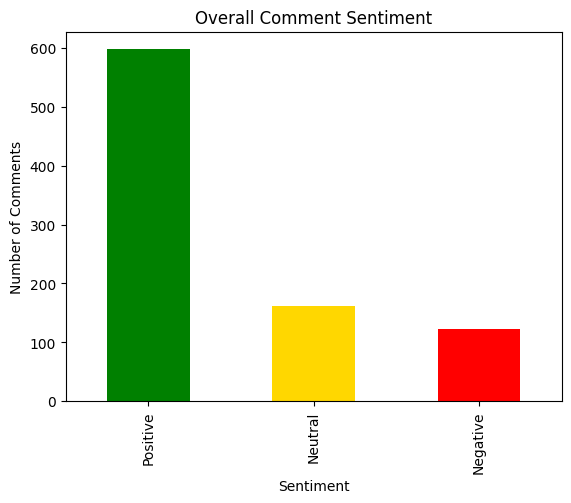

sentiment_label
Positive    598
Neutral     161
Negative    123
Name: count, dtype: int64

In [17]:
sentiment_counts = analysis_df['sentiment_label'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'gold', 'red'])
plt.title('Overall Comment Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.savefig('../Figures/overall_sentiment_distribution.png', bbox_inches='tight')
plt.show()

sentiment_counts

Majority of comments were positive, which was expected and pretty clear by just looking atthe data too. This reflects what the culture of the ATP mens tennis fanbase may be like.

#### Sentiments Based on Player

I then grouped the data by each of the players, and analyzed the average sentiments for each player. 

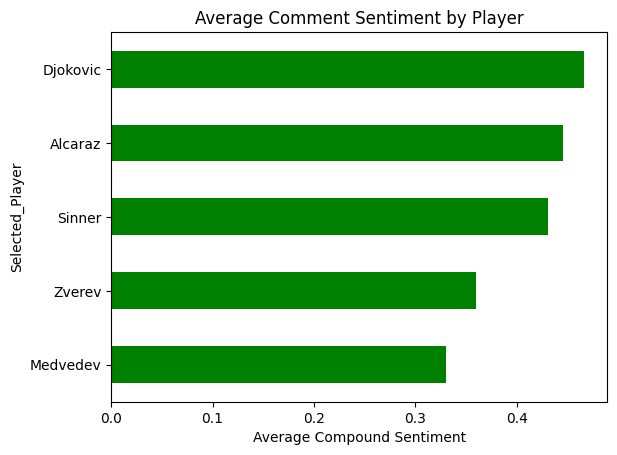

Selected_Player
Medvedev    0.330248
Zverev      0.360022
Sinner      0.430986
Alcaraz     0.445894
Djokovic    0.466095
Name: compound_score, dtype: float64

In [18]:
player_sentiment = analysis_df.groupby('Selected_Player')['compound_score'].mean().sort_values()
player_sentiment.plot(kind='barh', color='green')
plt.title('Average Comment Sentiment by Player')
plt.xlabel('Average Compound Sentiment')
plt.savefig('../Figures/average_sentiment_by_player.png', bbox_inches='tight')
plt.show()

player_sentiment

Without context of the players, this data may not mean much. Djokovic is often a fan favorite, as he has been a big name for a long time. He is well received across many groups. Medvedev is known as a "hot head" and s often very emotional on court, i a bad way. Fans don't always appreciate this, which is why he may have a lower average sentiment.

#### Sentiment During an Upset

I then analyzed whether an upset would cause any sift or change in sentiment.

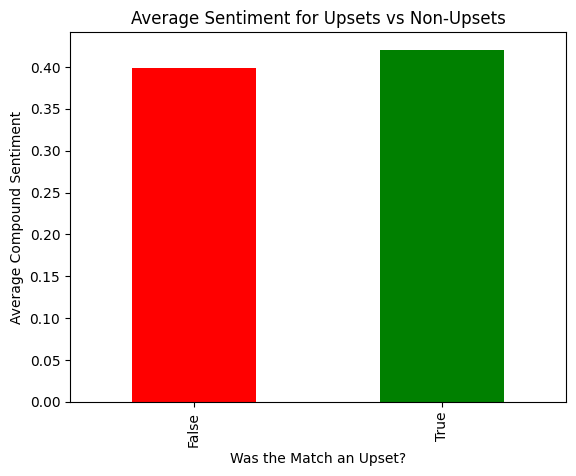

Upset
False    0.398792
True     0.420428
Name: compound_score, dtype: float64

In [19]:
upset_sentiment = analysis_df.groupby('Upset')['compound_score'].mean()
upset_sentiment.plot(kind='bar', color=['red', 'green'])
plt.title('Average Sentiment for Upsets vs Non-Upsets')
plt.xlabel('Was the Match an Upset?')
plt.ylabel('Average Compound Sentiment')
plt.savefig('../Figures/sentiment_upset_vs_nonupset.png', bbox_inches='tight')
plt.show()

upset_sentiment

These scores may not be statisticaly significant, as the sentiment scores are so close to eachother. Tennis fans often enjoy an upset, sometimes depending on who the players are. It would make sense if the overall sentiment of an upset was higher than a regular outcome, the fans like to root for an underdog.

#### Sentiment After Fan Favorite Loss

Because the five players chosen are relatively well liked amongst tennis fans, and they are better performing/popular, I wanted to see what the sentiment score was when they lost their match vs won it.

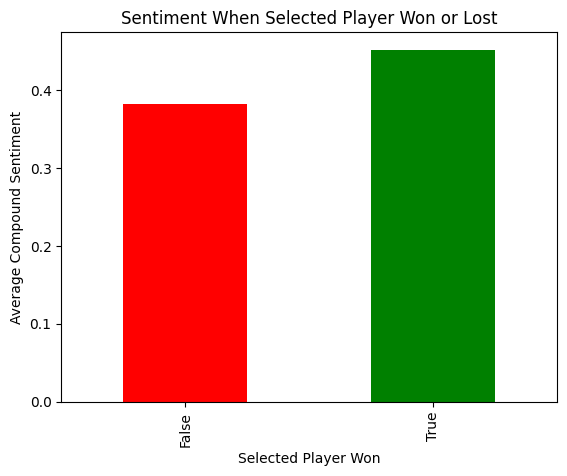

selected_player_won
False    0.381501
True     0.451578
Name: compound_score, dtype: float64

In [21]:
analysis_df['selected_player_won'] = analysis_df.apply(lambda row: row['Selected_Player'].lower() in row['Winner'].lower(), axis=1)

win_sentiment = analysis_df.groupby('selected_player_won')['compound_score'].mean()
win_sentiment.plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment When Selected Player Won or Lost')
plt.xlabel('Selected Player Won')
plt.ylabel('Average Compound Sentiment')
plt.savefig('../Figures/sentiment_selected_player_win_vs_loss.png', bbox_inches='tight')
plt.show()

win_sentiment

This result is a much bigger difference. There may be some data in the matches where these players are up against eachother. Still, the overall gist is that the fans like to see these players win, and are often dissapointed or sad when they don't win. 

#### Overall sentiment Distribution

This was mostly out of my own curiosity, but I wanted to see the distribution of compound scores across each of the players side by side. 

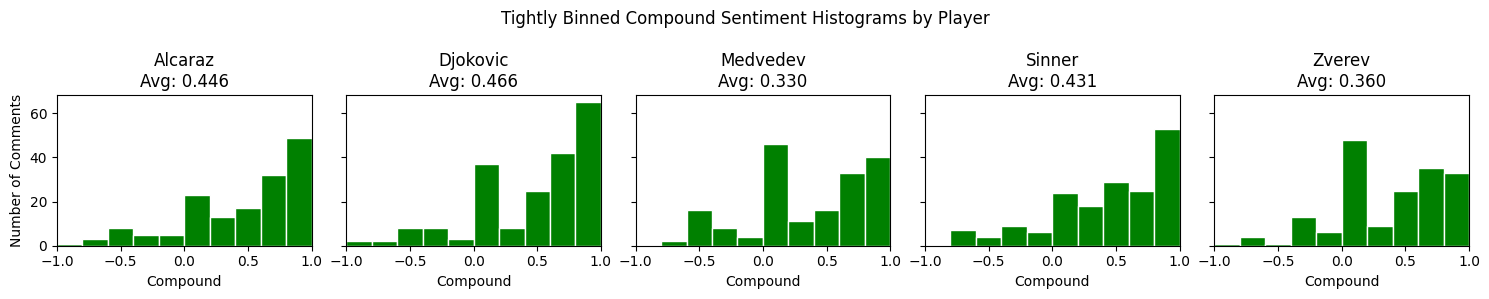

Selected_Player
Djokovic    0.466095
Alcaraz     0.445894
Sinner      0.430986
Zverev      0.360022
Medvedev    0.330248
Name: compound_score, dtype: float64

In [22]:
sentiment_bins = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]

players = sorted(analysis_df['Selected_Player'].dropna().unique())
fig, axes = plt.subplots(1, len(players), figsize=(15, 3), sharex=True, sharey=True)

for ax, player in zip(axes, players):
    player_scores = analysis_df.loc[analysis_df['Selected_Player'] == player, 'compound_score']
    avg_score = player_scores.mean()
    
    ax.hist(player_scores, bins=sentiment_bins, color='green', edgecolor='white')
    ax.set_title(f'{player}\nAvg: {avg_score:.3f}')
    ax.set_xlabel('Compound')
    ax.set_xlim(-1, 1)

axes[0].set_ylabel('Number of Comments')
fig.suptitle('Tightly Binned Compound Sentiment Histograms by Player')
plt.tight_layout(w_pad=0.5)
plt.savefig('../Figures/compound_sentiment_histograms_by_player.png', bbox_inches='tight')
plt.show()

analysis_df.groupby('Selected_Player')['compound_score'].mean().sort_values(ascending=False)